In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from efficientnet_pytorch import EfficientNet

In [2]:
model = EfficientNet.from_pretrained("efficientnet-b0")
model._fc = torch.nn.Linear(model._fc.in_features, 2)

model.load_state_dict(torch.load("../models/deeptrace_model.pth", map_location="cpu"))
model.eval()

print("Model Loaded Successfully")

Loaded pretrained weights for efficientnet-b0
Model Loaded Successfully


In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [4]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)

    probs = torch.softmax(output, dim=1)
    confidence, pred = torch.max(probs, dim=1)

    label = "Real" if pred.item() == 1 else "Fake"

    return label, confidence.item(), image

In [5]:
def visualize_prediction(image_path):

    label, confidence, image = predict_image(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")

    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}", fontsize=14)

    plt.show()

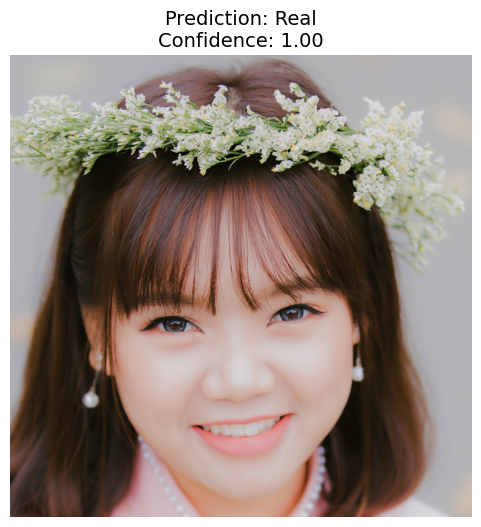

In [7]:
visualize_prediction("test.jpg")

In [8]:
def generate_heatmap(image_path):

    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    heatmap = cv2.applyColorMap(gray, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("DeepTrace Heatmap (Artifact Regions)")
    plt.axis("off")
    plt.show()

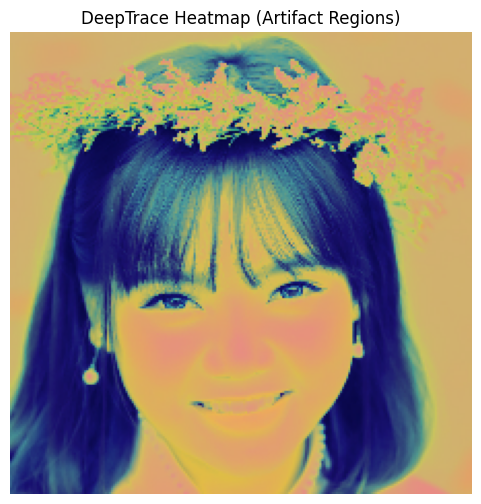

In [9]:
generate_heatmap("test.jpg")

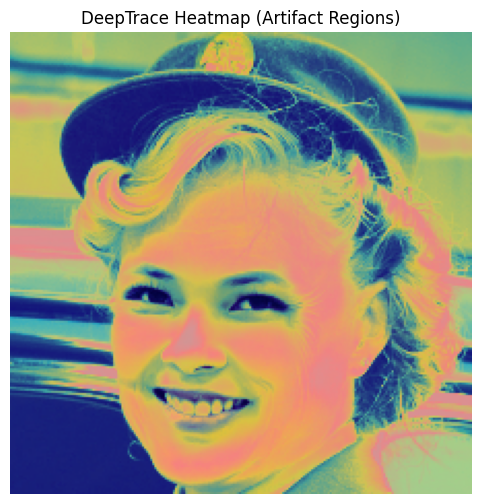

In [10]:
generate_heatmap("testt.jpg")

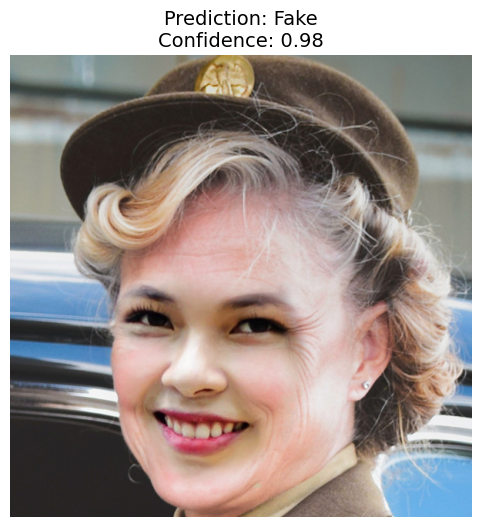

In [11]:
visualize_prediction("testt.jpg")

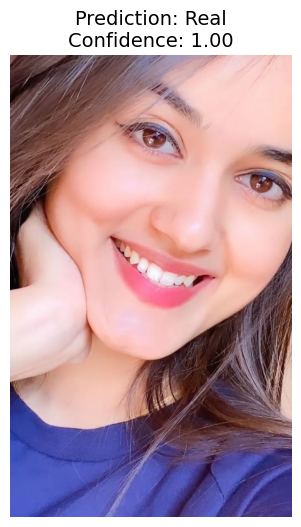

In [12]:
visualize_prediction("testtt.jpg")

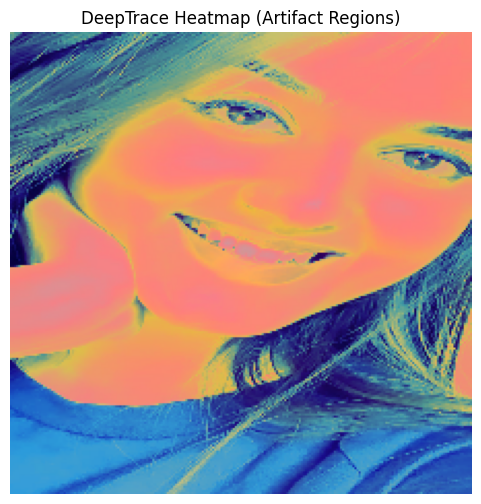

In [13]:
generate_heatmap("testtt.jpg")

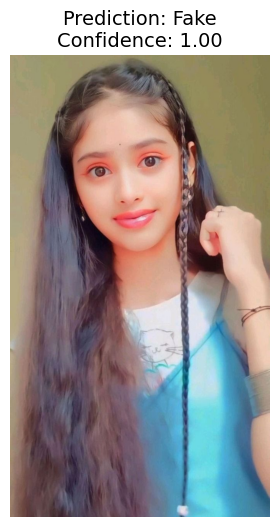

In [14]:
visualize_prediction("faketest.jpg")

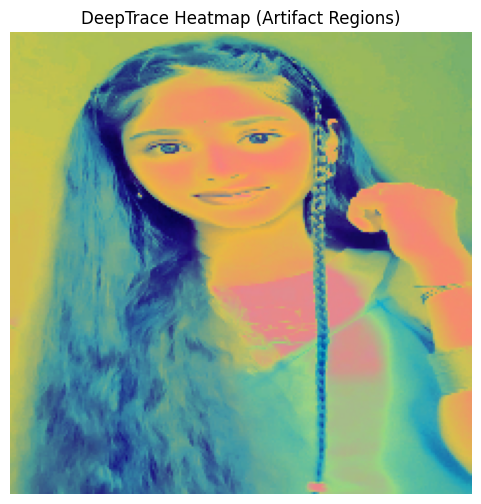

In [15]:
generate_heatmap("faketest.jpg")